# FIP 07 — DA × NE: correlation, transients, task responses

1. **Correlation and coherence** of the whole-session DA and NE traces.
2. **Large transients**: how often a large transient in one signal has a partner in the other.
3. **Task-aligned responses**: averages by outcome and by RPE within outcome, and trial-by-trial
   correlation of response size and peak latency. Drawn once per response window: 0.33–1 s
   (Rachel's), 0–0.5 s, 0.5–2 s and 0–2 s after the choice.

**Signals.** DA: dLight in lateral NAc (`latNAcc(X)-DA`). NE: GCaMP in LC noradrenergic axons
imaged in PL (`PL(X)-LCAxonCa`), i.e. axonal calcium. Both are `dff-bright_mc-iso-IRLS` dF/F at
20 Hz. The two indicators have different kinetics, so lags describe the recorded signals.

**Data.** The CSV-curated `DANE_3channels_curated` and `DANE_4channels_curated` assets. Each animal
contributes one hemisphere (the side with more sessions), with DA and NE from that side; animals
need at least 3 sessions.

**Code.** Figure 3 uses Rachel's pipeline on `data_z_norm` (session z-score minus each trial's mean
over the 1 s before the go cue): `dummy_nwb.load`, `trial_metrics.get_average_signal_window`,
`alignment.event_triggered_response`, and her `Qch-binned3` trial groups. Cross-correlation,
coherence, transient detection and latency use `fip_utils` (loading) and `signal_utils` on each
trace z-scored over the session.

**Statistics.** Each measure is computed per session. Tables give, per animal, the number of
sessions, the median and range of the effect across sessions and, where a per-session test exists,
the fraction of sessions with p < 0.05 and either the range of per-session p or, for tests against
a shift null, the median and range of each session's z-score against that null. Across animals: Wilcoxon
signed-rank on per-animal means (smallest two-sided p with 9 animals: 0.004); error bands are SEM
over animals.

**Conventions.** Positive lag or latency difference = NE later. Choice time and outcome time are
the same event (≤ 1 ms apart). Colors: DA vermillion, NE blue, rewarded orange, unrewarded grey,
totals black.

## Setup

In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import fip_utils as fu
import signal_utils as su
import stats_utils as st
import behavior_utils as bu
import plot_utils as pu
from rachel_analysis_utils.nwb_utils import dummy_nwb
from aind_dynamic_foraging_data_utils import alignment
from aind_dynamic_foraging_basic_analysis.metrics import trial_metrics
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
PAIRS_CACHE = ("/root/capsule/scratch/fip_05/pairs.pkl" if IS_CO
               else "../../data/fip_05_cache/pairs.pkl")
TRIAL_CACHE = ("/root/capsule/scratch/fip_07/trial_tables.pkl" if IS_CO
               else "../../data/fip_07_cache/trial_tables.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

FS = 20.0                    # Hz, grid rate for the continuous analyses
MIN_SESSIONS_PER_ANIMAL = 3

# ── Figure 1: cross-correlation and coherence ────────────────────────────────
MAXLAG_S = 3.0
N_SHIFT = 200                # circular shifts per session
MIN_SHIFT_S = 60.0           # smallest circular shift
COH_NPERSEG = 1024           # 51.2-s Welch segments
COH_BAND_HZ = (0.02, 2.0)    # coherence band tested; DA power at 2 Hz is ~1% of its low-frequency power
EXAMPLE_SESSION = None       # None = the session whose peak r is closest to the median
EXAMPLE_WINDOW_S, EXAMPLE_ZOOM_S = 180.0, 20.0

# ── Figure 2: large transients ───────────────────────────────────────────────
LARGE_PROM = 2.0             # z prominence of a "large" transient
PARTNER_PROM = 1.0           # z prominence that counts as a partner in the other signal
MATCH_WIN_S = 0.5            # partner must peak within this many s
MIN_SEP_S = 0.5              # minimum spacing of peaks in one signal
PROM_BINS = [2.0, 2.5, 3.0, 4.0, np.inf]
CONTEXTS = ["rewarded", "unrewarded", "cue, no response", "licking", "quiet"]

# ── Figure 3: task responses (Rachel's pipeline) ─────────────────────────────
DATA_COL = "data_z_norm"
ALIGN = "choice_time_in_session"          # = outcome time in these sessions
CUE = "goCue_start_time_in_session"
WINDOWS = {                               # s after the choice / outcome
    "rachel": (0.33, 1.0),                # Rachel's add_AUC_and_rpe_slope window
    "early": (0.0, 0.5),
    "late": (0.5, 2.0),
    "full": (0.0, 2.0),
}
WINDOW_LABEL = {"rachel": "Rachel 0.33–1 s", "early": "early 0–0.5 s", "late": "late 0.5–2 s",
                "full": "full 0–2 s"}
PSTH_T = (-1.0, 3.0)                      # choice-aligned traces
LATENCY_WIN = (0.0, 1.5)                  # peak search after the go cue
MIN_PEAK_Z = 1.0                          # a latency counts only if the peak clears this (z above baseline)
MIN_RPE_SD = 0.05                         # sessions with flatter within-outcome RPE are left out of the RPE panels
QCH_BINS = ["Qch 0", "Qch 0.33", "Qch 0.66"]

# ── Colors ───────────────────────────────────────────────────────────────────
SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"]}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)"}
OUT_COLOR = {"rewarded": OKABE_ITO["orange"], "unrewarded": "0.45"}
TOTAL_COLOR = "k"
NULL_COLOR = PALETTE["not_sig"]
# RPE bins, ordered from lowest to highest RPE within each outcome
RPE_BIN_COLOR = {"rewarded": plt.cm.Oranges(np.linspace(0.35, 0.9, 3)),
                 "unrewarded": plt.cm.Greys(np.linspace(0.85, 0.35, 3))}
rng = np.random.default_rng(0)

## Data

Sessions with a lateral-NAc DA fiber and a PL NE fiber on the same side (`fu.inventory_pairs`);
each animal's side with more sessions (`fu.choose_side`). For Figures 1–2 both traces are put on
one 20-Hz grid from 5 s before the first go cue to 10 s after the last (`fu.load_pairs`). Figure 3
loads the same sessions with `dummy_nwb.load`.

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

inv = fu.inventory_pairs(asset_roots)
kept, side_table = fu.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)
pairs = fu.load_pairs(kept, fs=FS, cache_path=PAIRS_CACHE)
for p in pairs:
    p["z"] = {s: su.zscore(p[s]) for s in ("da", "ne")}
    p["t"] = p["t0"] + np.arange(len(p["da"])) / FS

SUBJECTS = sorted({p["subject"] for p in pairs})
N_ANIMALS = len(SUBJECTS)
PAIR_SUBJECTS = [p["subject"] for p in pairs]
ANIMAL_STYLE = pu.animal_styles(SUBJECTS)
print(f"{len(pairs)} sessions from {N_ANIMALS} animals")
side_table[side_table.kept]

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data


loaded 97 pairs from cache ../../data/fip_05_cache/pairs.pkl
97 sessions from 9 animals


side,asset,L,R,side_used,n_used,kept
subject,,,,,,
800886,3ch,5,0,L,5,True
808054,4ch,1,16,R,16,True
809487,4ch,8,0,L,8,True
809491,4ch,20,0,L,20,True
815334,4ch,3,4,R,4,True
816212,4ch,8,0,L,8,True
816214,4ch,0,5,R,5,True
818585,3ch,8,0,L,8,True
818586,3ch,23,0,L,23,True


In [4]:
# Summary plots and statistics: pu.strip_by_measure, pu.strip_by_animal, pu.plot_mean_sem,
# st.stars, st.corr, st.group_means. The per-animal tables below are this notebook's own.

def per_animal(df, effect, p=None, z=None):
    """Per animal: sessions, median and range of `effect` across sessions, and per-session test summary.

    With `z` (a per-session z-score against a shift null) the median and range of z are given; the
    shift tests' p-values sit at their floor, so their range is not shown."""
    rows = []
    for subj, g in df.groupby("subject"):
        e = g[effect].dropna()
        r = dict(subject=subj, n_sessions=len(e), median=e.median(), min=e.min(), max=e.max())
        if p is not None:
            pv = g.loc[e.index, p]
            r["frac_p_lt_05"] = (pv < 0.05).mean()
            if z is None:
                r.update(p_min=pv.min(), p_max=pv.max())
        if z is not None:
            zv = g.loc[e.index, z]
            r.update(z_median=zv.median(), z_min=zv.min(), z_max=zv.max())
        rows.append(r)
    return pd.DataFrame(rows).set_index("subject")


def show_per_animal(title, df, effect, p=None, z=None, digits=3):
    """Print the per-animal table and the across-animal Wilcoxon on animal means."""
    t = per_animal(df, effect, p, z)
    m, pv, n = st.wilcoxon_animals(df.groupby("subject")[effect].mean())
    print(f"── {title} ── mean of animal means {m:+.3f}, Wilcoxon p = {pv:.4f} (n = {n})")
    fmt = {c: (lambda v: f"{v:.2g}") for c in ("p_min", "p_max")}
    fmt.update({c: (lambda v: f"{v:.1f}") for c in ("z_median", "z_min", "z_max")})
    print(t.to_string(float_format=lambda v: f"{v:.{digits}f}", formatters=fmt))
    print()


## Figure 1. Cross-correlation and coherence

Per session: the normalized cross-correlation of the two z-scored traces within ±3 s
(`fu.norm_xcorr(ne, da)`; positive lag = NE later) and magnitude-squared coherence (Welch, 51.2-s
segments). The null is 200 circular shifts of NE against DA by at least 60 s, which keep each
trace's autocorrelation and remove their alignment.

- **Cross-correlation test.** Peak |r| against the null's peak |r|; effect size = peak |r| minus
  the null median.
- **Coherence test.** Mean coherence over 0.02–2 Hz against the same mean for each shift; effect
  size = observed minus the null median. Above 2 Hz both signals carry little power (DA at 2 Hz is
  ~1% of its low-frequency power, at 5 Hz ~10⁻⁵).
- p = (1 + number of shifts ≥ observed) / 201, so the smallest per-session p is 0.005. Each session
  also gets z = (observed − null mean) / null SD, which grades sessions whose p is at that floor.

In [5]:
K_LAG = int(round(MAXLAG_S * FS))
LAGS = np.arange(-K_LAG, K_LAG + 1) / FS

rows = []
for p in pairs:
    da, ne = p["z"]["da"], p["z"]["ne"]
    _, cc, null = su.xcorr_shift_null(ne, da, FS, MAXLAG_S, N_SHIFT, MIN_SHIFT_S, rng)  # + lag = NE later
    f_coh, coh, coh_null = su.coherence_shift_null(da, ne, FS, COH_NPERSEG, N_SHIFT, MIN_SHIFT_S, rng)
    in_band = (f_coh >= COH_BAND_HZ[0]) & (f_coh <= COH_BAND_HZ[1])
    k = int(np.argmax(np.abs(cc)))
    null_peaks = np.abs(null).max(1)
    band_obs, band_null = coh[in_band].mean(), coh_null[:, in_band].mean(1)
    p.update(xc=cc, xc_null=null, coh=coh, coh_null=coh_null)
    rows.append(dict(subject=p["subject"], session=p["session"], peak_r=cc[k], peak_lag=LAGS[k],
                     r0=cc[K_LAG], null_peak=np.median(null_peaks),
                     null_peak_95=np.percentile(null_peaks, 95),
                     peak_r_effect=abs(cc[k]) - np.median(null_peaks),
                     p_xc=st.shift_p(abs(cc[k]), null_peaks), z_xc=st.shift_z(abs(cc[k]), null_peaks),
                     coh_band=band_obs, coh_null=np.median(band_null),
                     coh_effect=band_obs - np.median(band_null), p_coh=st.shift_p(band_obs, band_null),
                     z_coh=st.shift_z(band_obs, band_null)))
xc_sess = pd.DataFrame(rows)
IN_F = (f_coh >= COH_BAND_HZ[0]) & (f_coh <= COH_BAND_HZ[1])

# Grand means over animals, and the per-animal curves
xc_animal = st.group_means([p["xc"] for p in pairs], PAIR_SUBJECTS)[1]
xc_null_grand = st.group_means([p["xc_null"] for p in pairs], PAIR_SUBJECTS)[1].mean(0)
coh_animal = st.group_means([p["coh"] for p in pairs], PAIR_SUBJECTS)[1]
coh_null_grand = st.group_means([p["coh_null"] for p in pairs], PAIR_SUBJECTS)[1].mean(0)
coh_thr = np.percentile(coh_null_grand, 95, axis=0)

xc_by_animal = st.animal_means(xc_sess, ["peak_r", "peak_lag", "r0", "null_peak", "peak_r_effect",
                                         "coh_band", "coh_effect"], by_session=False)
k_an = np.argmax(np.abs(xc_animal), 1)
ANIMAL_ORDER = list(xc_by_animal["peak_r"].sort_values().index)
k_g = int(np.argmax(np.abs(xc_animal.mean(0))))
print(f"grand-mean cross-correlation: peak r = {xc_animal.mean(0)[k_g]:+.3f} at {LAGS[k_g]:+.2f} s\n")
show_per_animal("peak r", xc_sess, "peak_r", "p_xc", "z_xc")
show_per_animal("peak |r| minus shift-null median", xc_sess, "peak_r_effect", "p_xc", "z_xc")
show_per_animal("peak lag (s, + = NE later)", xc_sess, "peak_lag")
show_per_animal("coherence 0.02–2 Hz", xc_sess, "coh_band", "p_coh", "z_coh")
show_per_animal("coherence 0.02–2 Hz minus shift-null median", xc_sess, "coh_effect", "p_coh", "z_coh")

grand-mean cross-correlation: peak r = +0.265 at +0.05 s

── peak r ── mean of animal means +0.272, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median    min   max  frac_p_lt_05 z_median z_min z_max
subject                                                                    
800886            5   0.306  0.281 0.339         1.000     37.5  27.6  40.1
808054           16   0.272  0.212 0.340         1.000     28.6  23.7  36.6
809487            8   0.182  0.116 0.304         1.000     17.1  11.3  27.6
809491           20   0.342  0.257 0.521         1.000     46.8  20.5  62.2
815334            4   0.350  0.336 0.437         1.000     47.3  34.3  56.1
816212            8   0.090 -0.300 0.135         1.000     11.5   2.9  18.9
816214            5   0.354  0.313 0.422         1.000     34.0  20.1  39.2
818585            8   0.250  0.066 0.290         1.000     32.7   5.2  44.2
818586           23   0.317  0.257 0.395         1.000     36.2  24.1  45.0

── peak |r| minus shift-null median

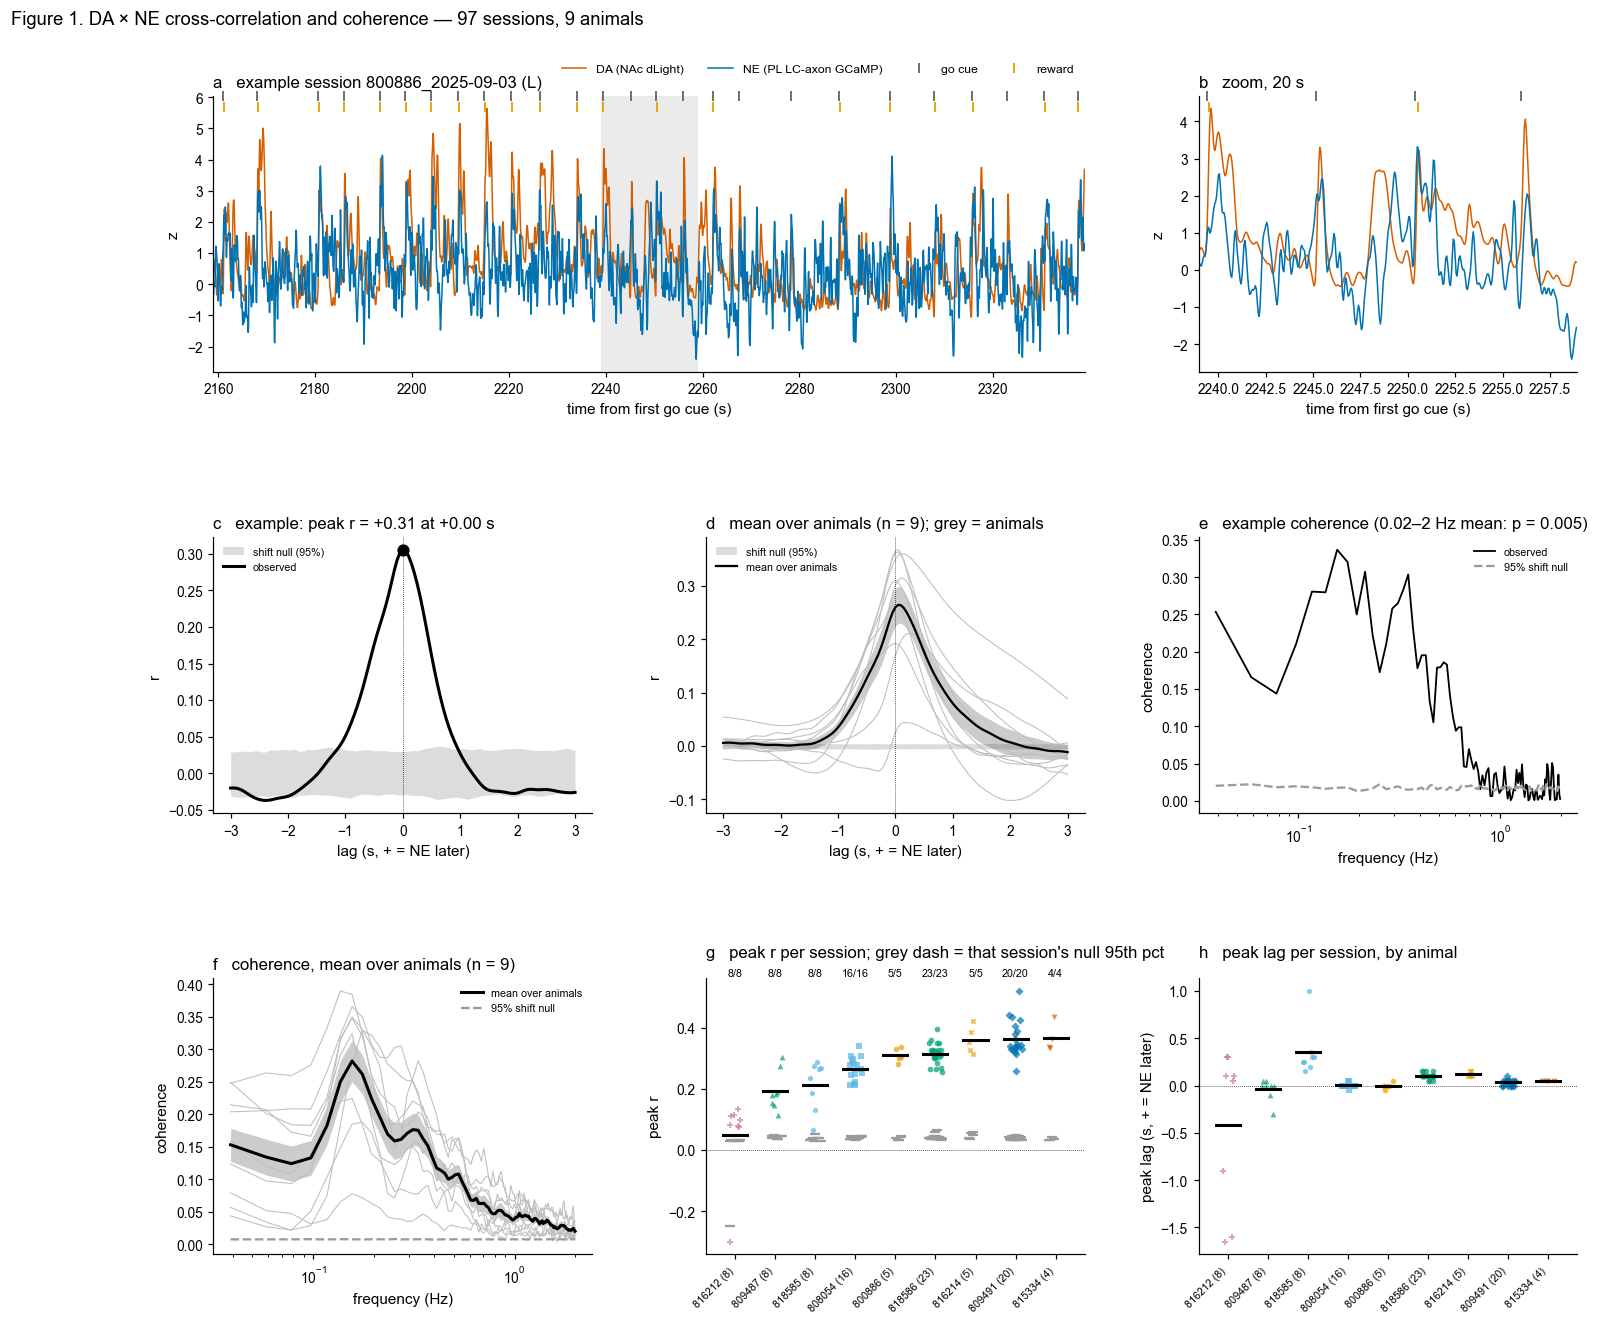

In [6]:
if EXAMPLE_SESSION is None:
    ex_i = int(np.argmin(np.abs(xc_sess.peak_r - xc_sess.peak_r.median())))
else:
    ex_i = next(i for i, p in enumerate(pairs) if p["session"] == EXAMPLE_SESSION)
ex = pairs[ex_i]
ex_row = xc_sess.iloc[ex_i]
ex_thr = np.percentile(ex["coh_null"], 95, axis=0)
t_mid = 0.5 * (ex["t"][0] + ex["t"][-1])
win_a = (t_mid - EXAMPLE_WINDOW_S / 2, t_mid + EXAMPLE_WINDOW_S / 2)
win_z = (t_mid - EXAMPLE_ZOOM_S / 2, t_mid + EXAMPLE_ZOOM_S / 2)


def plot_traces(ax, p, win, shade=None, legend=False):
    m = (p["t"] >= win[0]) & (p["t"] < win[1])
    for s in ("da", "ne"):
        ax.plot(p["t"][m], p["z"][s][m], color=SIG_COLOR[s], lw=1.0, label=SIG_LABEL[s])
    tr = p["trials"]
    for col, sel, c, lab in ((CUE, np.ones(len(tr), bool), PALETTE["neutral"], "go cue"),
                             ("reward_outcome_time_in_session", tr["earned_reward"].astype(bool),
                              OUT_COLOR["rewarded"], "reward")):
        t = tr.loc[sel, col].dropna().to_numpy()
        t = t[(t >= win[0]) & (t < win[1])]
        ax.plot(t, np.full(len(t), 1.0 if lab == "go cue" else 0.96), "|", color=c, ms=7, mew=1.2,
                label=lab, transform=ax.get_xaxis_transform(), clip_on=False)
    if shade:
        ax.axvspan(*shade, color=NULL_COLOR, alpha=0.2, lw=0)
    ax.set_xlim(win)
    ax.set_xlabel("time from first go cue (s)")
    ax.set_ylabel("z")
    if legend:
        ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.04), ncol=4, frameon=False, fontsize=8)
    style_ax(ax)


fig = plt.figure(figsize=(16, 13))
gs = GridSpec(3, 3, figure=fig, hspace=0.6, wspace=0.3, top=0.92)

ax = fig.add_subplot(gs[0, :2])
plot_traces(ax, ex, win_a, shade=win_z, legend=True)
ax.set_title(f"a   example session {ex['session']} ({ex['side']})", loc="left")
ax = fig.add_subplot(gs[0, 2])
plot_traces(ax, ex, win_z)
ax.set_title(f"b   zoom, {EXAMPLE_ZOOM_S:.0f} s", loc="left")

ax = fig.add_subplot(gs[1, 0])
lo, hi = np.percentile(ex["xc_null"], [2.5, 97.5], axis=0)
ax.fill_between(LAGS, lo, hi, color=NULL_COLOR, alpha=0.35, lw=0, label="shift null (95%)")
ax.plot(LAGS, ex["xc"], color=TOTAL_COLOR, lw=2, label="observed")
ax.plot(ex_row.peak_lag, ex_row.peak_r, "o", color=TOTAL_COLOR, ms=7)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("lag (s, + = NE later)")
ax.set_ylabel("r")
ax.set_title(f"c   example: peak r = {ex_row.peak_r:+.2f} at {ex_row.peak_lag:+.2f} s", loc="left")
ax.legend(fontsize=7, loc="upper left")
style_ax(ax)

ax = fig.add_subplot(gs[1, 1])
lo, hi = np.percentile(xc_null_grand, [2.5, 97.5], axis=0)
ax.fill_between(LAGS, lo, hi, color=NULL_COLOR, alpha=0.35, lw=0, label="shift null (95%)")
for i, c in enumerate(xc_animal):
    ax.plot(LAGS, c, color="0.75", lw=0.7)
pu.plot_mean_sem(ax, LAGS, list(xc_animal), TOTAL_COLOR, "mean over animals")
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("lag (s, + = NE later)")
ax.set_ylabel("r")
ax.set_title(f"d   mean over animals (n = {N_ANIMALS}); grey = animals", loc="left")
ax.legend(fontsize=7, loc="upper left")
style_ax(ax)

ax = fig.add_subplot(gs[1, 2])
ax.semilogx(f_coh[IN_F], ex["coh"][IN_F], color=TOTAL_COLOR, lw=1.2, label="observed")
ax.semilogx(f_coh[IN_F], ex_thr[IN_F], color=NULL_COLOR, lw=1.5, ls="--", label="95% shift null")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title(f"e   example coherence (0.02–2 Hz mean: p = {ex_row.p_coh:.3f})", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[2, 0])
for c in coh_animal:
    ax.semilogx(f_coh[IN_F], c[IN_F], color="0.75", lw=0.7)
pu.plot_mean_sem(ax, f_coh[IN_F], coh_animal[:, IN_F], TOTAL_COLOR, "mean over animals", lw=2)
ax.semilogx(f_coh[IN_F], coh_thr[IN_F], color=NULL_COLOR, lw=1.5, ls="--", label="95% shift null")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title(f"f   coherence, mean over animals (n = {N_ANIMALS})", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[2, 1])
pu.strip_by_animal(ax, xc_sess, "peak_r", ANIMAL_ORDER, "peak r", styles=ANIMAL_STYLE, null_col="null_peak_95", p_col="p_xc")
ax.set_title("g   peak r per session; grey dash = that session's null 95th pct", loc="left", pad=14)
ax = fig.add_subplot(gs[2, 2])
pu.strip_by_animal(ax, xc_sess, "peak_lag", ANIMAL_ORDER, "peak lag (s, + = NE later)", styles=ANIMAL_STYLE)
ax.set_title("h   peak lag per session, by animal", loc="left", pad=14)

fig.suptitle(f"Figure 1. DA × NE cross-correlation and coherence — {len(pairs)} sessions, "
             f"{N_ANIMALS} animals", x=0.01, ha="left")
save_fig(fig, "fip_07_fig1_xcorr_coherence", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## Figure 2. Large transients with and without a partner

Transients are peaks of each z-scored trace found by `scipy.signal.find_peaks`
(`su.detect_transients`, peaks at least `MIN_SEP_S` apart).
**Prominence** is a peak's height above the higher of the two troughs that separate it from
higher neighboring peaks, so a transient riding on a slow rise is scored by its own size. A
transient is **large** at prominence ≥ `LARGE_PROM` z. It has a **partner** if the other signal
has a transient of prominence ≥ `PARTNER_PROM` z within ±`MATCH_WIN_S` s, and is **solo**
otherwise. Chance is the matched fraction when the other signal's transient train is circularly
shifted (100 shifts per session); the per-session p is the fraction of shifts with a matched
fraction at least as high, and z is the observed matched fraction in SDs of the shifts above their
mean. The chance-corrected coupling is (observed − chance) / (1 − chance).

Each transient also gets a task context from its peak time (`bu.label_context`), first rule that
applies: 0–1.5 s after a rewarded or an unrewarded outcome; 0–1.5 s after the go cue of an ignored
trial; a lickometer contact within ±1 s ("licking"); otherwise "quiet" (away from outcomes and
spout contacts, not measured stillness).

Panels g–h average both signals' traces around the peaks of large transients in one signal, split
by whether that transient had a partner. Color is the trace (DA or NE), line style is the group of
peaks. Solo is defined by the absence of a partner peak within the shaded ±0.5 s, so the other
trace is flat there by construction and can still rise just outside it.

In [7]:
trans_rows, pair_rows = [], []
for p in pairs:
    z = p["z"]
    dur = len(z["da"]) / FS
    det = {s: su.detect_transients(z[s], FS, prominence=PARTNER_PROM, min_sep_s=MIN_SEP_S)
           for s in ("da", "ne")}
    for s in ("da", "ne"):
        d = det[s]
        d["t"] = p["t0"] + d["i"] / FS
        d["context"] = bu.label_context(d["t"].to_numpy(), p["trials"], p["licks"])
        d["sig"], d["subject"], d["session"] = s, p["subject"], p["session"]
        trans_rows.append(d)
    for s, o in (("da", "ne"), ("ne", "da")):
        big = det[s][det[s]["prominence"] >= LARGE_PROM]
        idx, lag = su.nearest_partner(big["t"].to_numpy(), det[o]["t"].to_numpy())
        null = su.coincidence_null(big["t"].to_numpy(), det[o]["t"].to_numpy(),
                                   -MATCH_WIN_S, MATCH_WIN_S, span=(p["t0"], p["t0"] + dur),
                                   n_shift=100, rng=rng)
        obs = np.mean(np.abs(lag) <= MATCH_WIN_S) if len(big) else np.nan
        pair_rows.append(pd.DataFrame(dict(
            subject=p["subject"], session=p["session"], sig=s, t=big["t"].values,
            prominence=big["prominence"].values, context=big["context"].values, lag=lag,
            partner_prom=det[o]["prominence"].to_numpy()[idx] if len(det[o]) else np.nan,
            null_frac=np.nanmean(null), p_couple=st.shift_p(obs, null), z_couple=st.shift_z(obs, null),
            dur=dur)))
transients = pd.concat(trans_rows, ignore_index=True)
paired = pd.concat(pair_rows, ignore_index=True)
paired["matched"] = paired["lag"].abs() <= MATCH_WIN_S
paired["solo"] = ~paired["matched"]

rows = []
for (subj, sess, sig), g in paired.groupby(["subject", "session", "sig"]):
    matched, chance = g["matched"].mean(), g["null_frac"].iloc[0]
    rows.append(dict(subject=subj, session=sess, sig=sig, rate_per_min=len(g) / g["dur"].iloc[0] * 60,
                     solo_frac=1 - matched, chance_solo=1 - chance,
                     coupling=(matched - chance) / (1 - chance), p_couple=g["p_couple"].iloc[0],
                     z_couple=g["z_couple"].iloc[0]))
solo_sess = pd.DataFrame(rows)
solo_animal = (solo_sess.groupby(["subject", "sig"])
               [["rate_per_min", "solo_frac", "chance_solo", "coupling"]].mean().unstack("sig"))
solo_animal.columns = [f"{a}_{b}" for a, b in solo_animal.columns]

paired["prom_bin"] = pd.cut(paired["prominence"], PROM_BINS, right=False)
size_curve = (paired.groupby(["subject", "sig", "prom_bin"], observed=True)["solo"].mean()
              .unstack("prom_bin"))
solo_by_ctx = (paired.groupby(["subject", "sig", "context"])["solo"].mean()
               .unstack("context").groupby(level="sig").mean())[CONTEXTS]

ETA_LAGS = np.arange(-2.0, 3.0 + 1e-9, 1 / FS)
eta = {}
for subj in SUBJECTS:
    acc = {}
    for p in (p for p in pairs if p["subject"] == subj):
        g = paired[paired.session == p["session"]]
        for s in ("da", "ne"):
            for solo in (True, False):
                t = g[(g.sig == s) & (g.solo == solo)]["t"].to_numpy()
                if len(t) < 3:
                    continue
                for o in ("da", "ne"):
                    acc.setdefault((s, solo, o), []).append(
                        np.nanmean(su.peri_event_grid(p["z"][o], p["t0"], FS, t, ETA_LAGS), 0))
    for k, v in acc.items():
        eta.setdefault(k, []).append(np.mean(v, 0))

for sig, lab in (("da", "DA"), ("ne", "NE")):
    g = solo_sess[solo_sess.sig == sig]
    show_per_animal(f"large {lab} transients / min", g, "rate_per_min")
    show_per_animal(f"{lab} solo fraction", g, "solo_frac")
    show_per_animal(f"{lab} chance-corrected coupling", g, "coupling", "p_couple", "z_couple")
print("solo fraction by context (mean over animals):")
print(solo_by_ctx.round(2).to_string())

── large DA transients / min ── mean of animal means +8.722, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median    min    max
subject                                  
800886            5   9.510  8.783 10.058
808054           16   8.591  7.784  9.669
809487            8   5.667  5.050  7.304
809491           20   7.420  6.115  9.233
815334            4   9.218  8.053  9.933
816212            8  12.378 10.363 13.340
816214            5   6.842  6.274  7.398
818585            8  10.614  8.801 12.640
818586           23   8.484  7.098  9.392

── DA solo fraction ── mean of animal means +0.174, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median   min   max
subject                                
800886            5   0.086 0.080 0.114
808054           16   0.227 0.120 0.264
809487            8   0.188 0.108 0.244
809491           20   0.122 0.070 0.149
815334            4   0.096 0.081 0.117
816212            8   0.163 0.141 0.326
816214            5   0.362 0.309 0.421
818585  

In [8]:
# Panel a: a 20-s stretch of the Figure 1 example session holding a matched large DA transient,
# a matched large NE transient and a solo large NE transient, for the schematic.
SNIP_S = 20.0
g = paired[paired.session == ex["session"]]
best = None
for t0 in np.arange(ex["t"][0] + 5, ex["t"][-1] - SNIP_S, 2.0):
    w = g[(g.t >= t0 + 2) & (g.t < t0 + SNIP_S - 2)]
    ok = (((w.sig == "da") & w.matched).any() and ((w.sig == "ne") & w.solo).any()
          and ((w.sig == "ne") & w.matched).any())
    if ok and (best is None or abs(t0 - t_mid) < abs(best - t_mid)):
        best = t0
snip = (best, best + SNIP_S) if best is not None else win_z
print("schematic window:", np.round(snip, 1))


def plot_schematic(ax, p, win):
    m = (p["t"] >= win[0]) & (p["t"] < win[1])
    offset = {"da": 0.0, "ne": -6.0}        # NE drawn below DA
    tr_s = transients[(transients.session == p["session"])]
    pr_s = paired[paired.session == p["session"]]
    for s in ("da", "ne"):
        y = p["z"][s] + offset[s]
        ax.plot(p["t"][m], y[m], color=SIG_COLOR[s], lw=1.1, label=SIG_LABEL[s])
        d = tr_s[(tr_s.sig == s) & (tr_s.t >= win[0]) & (tr_s.t < win[1])]
        large = d[d.prominence >= LARGE_PROM]
        small = d[d.prominence < LARGE_PROM]
        ax.scatter(small.t, y[small.i.to_numpy()], s=28, facecolor="white", edgecolor=SIG_COLOR[s], lw=1.2,
                   zorder=4, label=f"{s.upper()} partner-level ({PARTNER_PROM:g}–{LARGE_PROM:g} z)")
        ax.scatter(large.t, y[large.i.to_numpy()], s=36, color=SIG_COLOR[s], zorder=4,
                   label=f"{s.upper()} large (≥ {LARGE_PROM:g} z)")
        for _, r in large.iterrows():                       # prominence: peak minus its base
            ax.plot([r.t, r.t], [y[int(r.i)] - r.prominence, y[int(r.i)]], color=SIG_COLOR[s], lw=1.6,
                    alpha=0.6)
        solo = pr_s[(pr_s.sig == s) & pr_s.solo & (pr_s.t >= win[0]) & (pr_s.t < win[1])]
        for _, r in solo.iterrows():
            ax.annotate("solo", (r.t, y[int(round((r.t - p["t0"]) * FS))]), xytext=(0, 10),
                        textcoords="offset points", ha="center", fontsize=8, color=SIG_COLOR[s])
    da_large = pr_s[(pr_s.sig == "da") & (pr_s.t >= win[0]) & (pr_s.t < win[1])]
    for k, (_, r) in enumerate(da_large.iterrows()):          # match window around each large DA peak
        ax.axvspan(r.t - MATCH_WIN_S, r.t + MATCH_WIN_S, color="0.85", alpha=0.6, lw=0, zorder=0,
                   label=f"±{MATCH_WIN_S:g} s match window" if k == 0 else None)
    if len(da_large):
        r = da_large.iloc[0]
        i = int(round((r.t - p["t0"]) * FS))
        ax.annotate("prominence", (r.t, p["z"]["da"][i] - r.prominence / 2), xytext=(8, 0),
                    textcoords="offset points", fontsize=8, va="center", color=SIG_COLOR["da"])
    ax.set_xlim(win)
    ax.set_yticks([])
    ax.set_xlabel("time from first go cue (s)")
    ax.set_ylabel("z (NE offset below DA)")
    ax.legend(fontsize=7, ncol=4, loc="lower right", bbox_to_anchor=(1.0, 1.02), frameon=False)
    style_ax(ax)

schematic window: [2246. 2266.]


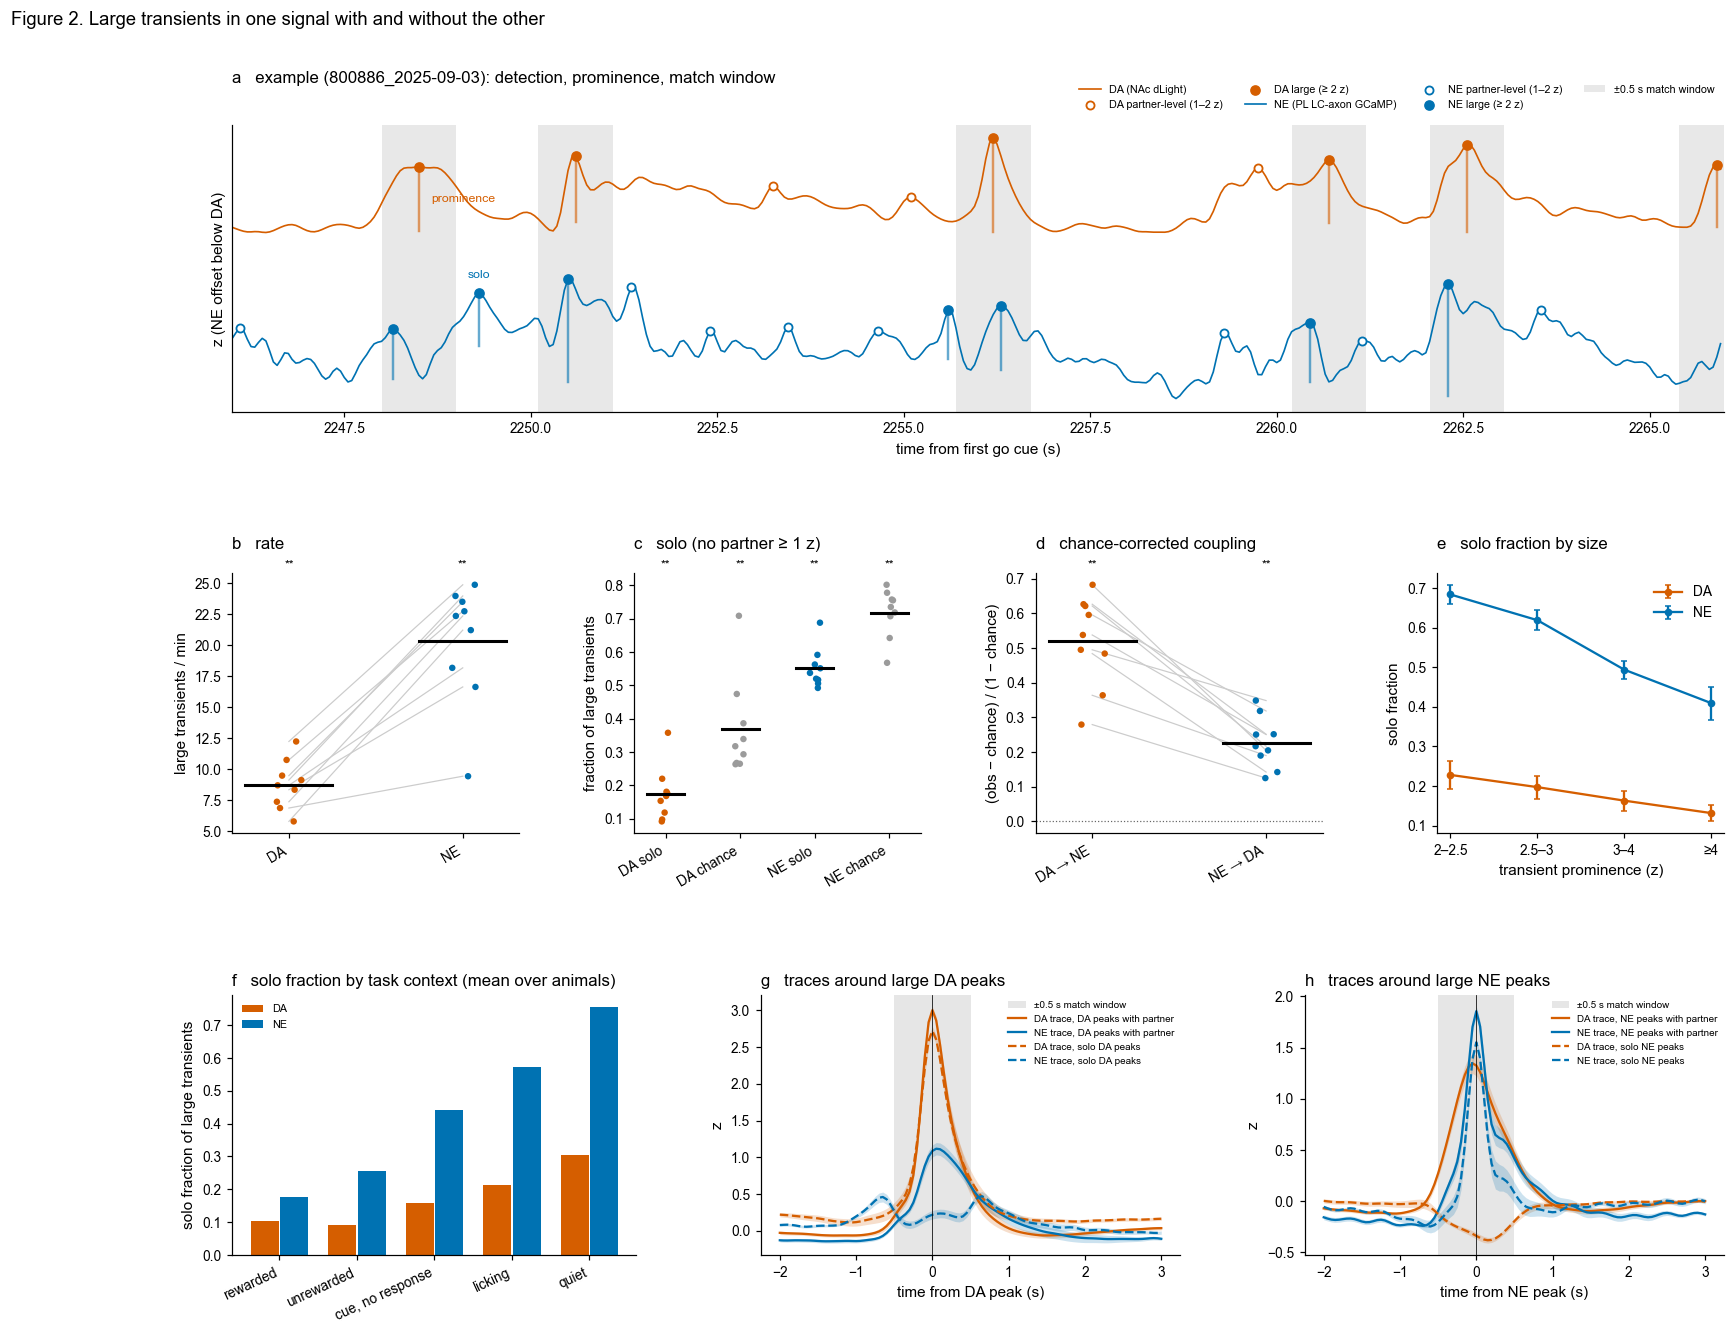

In [9]:
fig = plt.figure(figsize=(17.5, 13))
gs = GridSpec(3, 4, figure=fig, hspace=0.6, wspace=0.4, top=0.9, height_ratios=[1.1, 1, 1])
row3 = gs[2, :].subgridspec(1, 3, width_ratios=[1.3, 1.35, 1.35], wspace=0.3)

ax = fig.add_subplot(gs[0, :])
plot_schematic(ax, ex, snip)
ax.set_title(f"a   example ({ex['session']}): detection, prominence, match window", loc="left",
             pad=28)

ax = fig.add_subplot(gs[1, 0])
pu.strip_by_measure(ax, solo_animal, ["rate_per_min_da", "rate_per_min_ne"], ["DA", "NE"],
             [SIG_COLOR["da"], SIG_COLOR["ne"]], "large transients / min", title="b   rate",
             zero=False)
ax = fig.add_subplot(gs[1, 1])
pu.strip_by_measure(ax, solo_animal, ["solo_frac_da", "chance_solo_da", "solo_frac_ne", "chance_solo_ne"],
             ["DA solo", "DA chance", "NE solo", "NE chance"],
             [SIG_COLOR["da"], NULL_COLOR, SIG_COLOR["ne"], NULL_COLOR],
             "fraction of large transients", title=f"c   solo (no partner ≥ {PARTNER_PROM:g} z)",
             zero=False, connect=False)
ax = fig.add_subplot(gs[1, 2])
pu.strip_by_measure(ax, solo_animal, ["coupling_da", "coupling_ne"], ["DA → NE", "NE → DA"],
             [SIG_COLOR["da"], SIG_COLOR["ne"]], "(obs − chance) / (1 − chance)",
             title="d   chance-corrected coupling")
ax = fig.add_subplot(gs[1, 3])
x = np.arange(len(PROM_BINS) - 1)
for s in ("da", "ne"):
    c = size_curve.xs(s, level="sig")
    ax.errorbar(x, *st.mean_sem(c)[:2], color=SIG_COLOR[s],
                marker="o", ms=4, capsize=2, label=s.upper())
ax.set_xticks(x)
ax.set_xticklabels(["2–2.5", "2.5–3", "3–4", "≥4"])
ax.set_xlabel("transient prominence (z)")
ax.set_ylabel("solo fraction")
ax.set_title("e   solo fraction by size", loc="left", pad=16)
ax.legend()
style_ax(ax)

ax = fig.add_subplot(row3[0])
xx = np.arange(len(CONTEXTS))
for k, s in enumerate(("da", "ne")):
    ax.bar(xx + (k - 0.5) * 0.38, solo_by_ctx.loc[s], width=0.36, color=SIG_COLOR[s],
           label=f"{s.upper()}")
ax.set_xticks(xx)
ax.set_xticklabels(CONTEXTS, rotation=25, ha="right")
ax.set_ylabel("solo fraction of large transients")
ax.set_title("f   solo fraction by task context (mean over animals)", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

for k, (s, title) in enumerate((("da", "g   traces around large DA peaks"),
                                ("ne", "h   traces around large NE peaks"))):
    ax = fig.add_subplot(row3[1 + k])
    ax.axvspan(-MATCH_WIN_S, MATCH_WIN_S, color="0.9", lw=0, zorder=0,
               label=f"±{MATCH_WIN_S:g} s match window")
    for solo, ls in ((False, "-"), (True, "--")):
        for o in ("da", "ne"):
            if (s, solo, o) in eta:
                which = f"solo {s.upper()} peaks" if solo else f"{s.upper()} peaks with partner"
                pu.plot_mean_sem(ax, ETA_LAGS, eta[(s, solo, o)], SIG_COLOR[o],
                            f"{o.upper()} trace, {which}", ls=ls)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel(f"time from {s.upper()} peak (s)")
    ax.set_ylabel("z")
    ax.set_title(title, loc="left")
    ax.legend(fontsize=6.5, loc="upper right", frameon=False, handlelength=1.8,
              borderaxespad=0.2)
    style_ax(ax)

fig.suptitle("Figure 2. Large transients in one signal with and without the other", x=0.01,
             ha="left")
save_fig(fig, "fip_07_fig2_transients", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## Figure 3. Task-aligned responses and their trial-by-trial coupling

Everything here runs through Rachel's pipeline on `data_z_norm`. Per session and signal:

- **Response size**: `trial_metrics.get_average_signal_window` (her `add_AUC_and_rpe_slope` step),
  the mean `data_z_norm` in each window after the choice. With her window it reproduces the
  `avg_data_z_norm_<channel>_choice_time` column her pipeline stored.
- **Aligned traces**: `alignment.event_triggered_response`, choice-aligned, one row per responded
  trial.
- **Peak latency**: the same function, go-cue-aligned; the latency is the time of the maximum
  0–1.5 s after the cue. It counts only if the maximum is ≥ `MIN_PEAK_Z` above the pre-cue baseline
  and not on the window's first or last sample, in both signals.
- **RPE groups** (panels e–h): Rachel's `Qch-binned3`, outcome × Q_chosen in thirds.
  `RPE_earned` = earned reward − Q_chosen, so within an outcome each group is one RPE range. Left
  out of these panels: sessions whose within-outcome RPE SD is below `MIN_RPE_SD`, and trials
  before a session's first reward (Q_chosen still at its initial value, 0).

Trials: responded, without extra (unearned) water. Correlations (c, d) are per session across
trials: **total** uses all trials, **within rewarded / unrewarded** only trials of that outcome.
The first run takes about 15 minutes and is cached.

In [10]:
def session_trial_table(row):
    """Rachel-pipeline per-trial measures and choice-aligned traces for one session."""
    nwb = dummy_nwb.load(row.path, load_fip=True)
    tr = nwb.df_trials.copy()
    resp = tr[(tr["animal_response"] < 2) & tr[ALIGN].notna() & tr[CUE].notna()].sort_values(ALIGN)
    psth = {}
    for sig, ch in (("da", row.da_event), ("ne", row.ne_event)):
        for w, (a, b) in WINDOWS.items():
            col = f"{sig}_{w}"
            out = trial_metrics.get_average_signal_window(nwb, ALIGN, [a, b], ch,
                                                          data_column=DATA_COL, output_col=col)
            tr = tr.merge(out[["trial", col]], on="trial", how="left")
        d = nwb.df_fip.query("event == @ch")
        # choice-aligned traces (3a, 3b)
        etr = alignment.event_triggered_response(d, "timestamps", DATA_COL, resp[ALIGN].to_numpy(),
                                                 t_start=PSTH_T[0], t_end=PSTH_T[1],
                                                 output_sampling_rate=FS, censor=True)
        M = etr.pivot(index="event_number", columns="time", values=DATA_COL)
        psth[sig] = M.reindex(range(len(resp))).to_numpy(np.float32)
        psth_t = M.columns.to_numpy()
        # go-cue-aligned peak latency (3d)
        cue_times = resp[CUE].to_numpy()
        order = np.argsort(cue_times)
        etr = alignment.event_triggered_response(d, "timestamps", DATA_COL, cue_times[order],
                                                 t_start=LATENCY_WIN[0], t_end=LATENCY_WIN[1],
                                                 output_sampling_rate=FS, censor=True,
                                                 include_endpoint=False)
        C = etr.pivot(index="event_number", columns="time", values=DATA_COL)
        C = C.reindex(range(len(resp))).to_numpy()
        C_trial = np.full_like(C, np.nan)
        C_trial[order] = C                           # back to choice order
        ok = np.isfinite(C_trial).all(1)
        k = np.full(len(resp), -1)
        k[ok] = np.argmax(C_trial[ok], 1)
        lat_t = etr["time"].drop_duplicates().sort_values().to_numpy()
        lat = pd.Series(np.where(k >= 0, lat_t[np.clip(k, 0, None)], np.nan), index=resp["trial"])
        peak = pd.Series(np.where(ok, np.nanmax(np.where(ok[:, None], C_trial, 0), 1), np.nan),
                         index=resp["trial"])
        edge = pd.Series((k == 0) | (k == len(lat_t) - 1), index=resp["trial"])
        tr[f"{sig}_lat"] = tr["trial"].map(lat)
        tr[f"{sig}_peak"] = tr["trial"].map(peak)
        tr[f"{sig}_edge"] = tr["trial"].map(edge)
        stored = f"avg_{DATA_COL}_{ch}_choice_time"
        tr[f"{sig}_stored"] = tr[stored] if stored in tr else np.nan
    keep = ["trial", "animal_response", "earned_reward", "extra_reward", "RPE_earned", "Q_chosen",
            "Qch-binned3", "response_time", ALIGN] + [c for c in tr if c[:3] in ("da_", "ne_")]
    return dict(subject=row.subject, session=row.session, trials=tr[keep],
                psth=psth, psth_trial=resp["trial"].to_numpy(), psth_t=psth_t)


key = (tuple(kept["path"]), tuple(WINDOWS.items()), PSTH_T, LATENCY_WIN, DATA_COL, FS)
if os.path.exists(TRIAL_CACHE) and pickle.load(open(TRIAL_CACHE, "rb"))["key"] == key:
    sess_tables = pickle.load(open(TRIAL_CACHE, "rb"))["tables"]
    print(f"loaded {len(sess_tables)} sessions from {TRIAL_CACHE}")
else:
    sess_tables = []
    for i, row in enumerate(kept.itertuples()):
        sess_tables.append(session_trial_table(row))
        if (i + 1) % 10 == 0:
            print(f"  {i + 1} / {len(kept)}")
    os.makedirs(os.path.dirname(os.path.abspath(TRIAL_CACHE)), exist_ok=True)
    pickle.dump(dict(key=key, tables=sess_tables), open(TRIAL_CACHE, "wb"))
PSTH_TIME = sess_tables[0]["psth_t"]

loaded 97 sessions from ../../data/fip_07_cache/trial_tables.pkl


In [11]:
T = pd.concat([s["trials"].assign(subject=s["subject"], session=s["session"]) for s in sess_tables],
              ignore_index=True)
T["responded"] = T["animal_response"] < 2
T["extra"] = T["extra_reward"].fillna(0).astype(bool)
T["rewarded"] = T["earned_reward"].fillna(0).astype(bool) & T["responded"]
trials = T[T.responded & ~T.extra].copy()

# exclusions for the RPE panels
rpe_sd = trials.groupby(["session", "rewarded"])["RPE_earned"].std().unstack().min(axis=1)
FLAT_RPE = set(rpe_sd.index[rpe_sd < MIN_RPE_SD])
trials["before_first_reward"] = (trials.groupby("session")["rewarded"]
                                 .transform(lambda r: r.cumsum().shift(fill_value=0) == 0))
trials["qbin"] = trials["Qch-binned3"].astype(str).str.extract(r"\((Qch [\d.]+)\)")[0]
print(f"{len(trials)} responded trials without extra water; "
      f"{T.responded.sum() - len(trials)} with extra water left out")
print("left out of the RPE panels: flat-RPE sessions", sorted(FLAT_RPE),
      f"and {int(trials.before_first_reward.sum())} trials before the first reward")

# Rachel's window, recomputed with her function, against the column her pipeline stored
for sig in ("da", "ne"):
    d = trials[[f"{sig}_rachel", f"{sig}_stored"]].dropna()
    print(f"{sig}: {len(d)} trials, max |recomputed − stored| = "
          f"{(d[f'{sig}_rachel'] - d[f'{sig}_stored']).abs().max():.2g}")

43903 responded trials without extra water; 393 with extra water left out
left out of the RPE panels: flat-RPE sessions ['816212_2025-12-10', '818586_2026-01-05'] and 238 trials before the first reward
da: 43794 trials, max |recomputed − stored| = 0
ne: 43794 trials, max |recomputed − stored| = 0


In [12]:
# Panels a, b, e–h: session mean trace per group, then per animal
def group_traces(select):
    """{(sig, group): [per-animal mean trace]} for groups given by select(trials_of_session)."""
    out = {}
    for subj in SUBJECTS:
        acc = {}
        for s in (s for s in sess_tables if s["subject"] == subj):
            t = trials[trials.session == s["session"]].set_index("trial")
            row_of = {tr: i for i, tr in enumerate(s["psth_trial"])}
            for grp, trial_ids in select(t).items():
                rows = [row_of[x] for x in trial_ids if x in row_of]
                if len(rows) < 3:
                    continue
                for sig in ("da", "ne"):
                    acc.setdefault((sig, grp), []).append(np.nanmean(s["psth"][sig][rows], 0))
        for k, v in acc.items():
            out.setdefault(k, []).append(np.mean(v, 0))
    return out


by_outcome = group_traces(lambda t: {"rewarded": t.index[t.rewarded],
                                     "unrewarded": t.index[~t.rewarded]})


def rpe_groups(t):
    if t.empty or t["session"].iloc[0] in FLAT_RPE:
        return {}
    t = t[~t.before_first_reward]
    return {(out, q): t.index[(t.rewarded == (out == "rewarded")) & (t.qbin == q)]
            for out in ("rewarded", "unrewarded") for q in QCH_BINS}


by_rpe = group_traces(rpe_groups)
# RPE range of each Q_chosen third within an outcome, ordered from low to high RPE
RPE_ORDER = {"rewarded": ["Qch 0.66", "Qch 0.33", "Qch 0"],        # RPE = 1 − Q
             "unrewarded": ["Qch 0.66", "Qch 0.33", "Qch 0"]}      # RPE = −Q
RPE_RANGE = {("rewarded", "Qch 0.66"): "RPE 0–0.33", ("rewarded", "Qch 0.33"): "RPE 0.33–0.67",
             ("rewarded", "Qch 0"): "RPE 0.67–1", ("unrewarded", "Qch 0.66"): "RPE −1 to −0.67",
             ("unrewarded", "Qch 0.33"): "RPE −0.67 to −0.33", ("unrewarded", "Qch 0"): "RPE −0.33–0"}
print({k: len(v) for k, v in by_rpe.items()})

{('da', ('rewarded', 'Qch 0')): 9, ('ne', ('rewarded', 'Qch 0')): 9, ('da', ('rewarded', 'Qch 0.33')): 9, ('ne', ('rewarded', 'Qch 0.33')): 9, ('da', ('rewarded', 'Qch 0.66')): 9, ('ne', ('rewarded', 'Qch 0.66')): 9, ('da', ('unrewarded', 'Qch 0')): 9, ('ne', ('unrewarded', 'Qch 0')): 9, ('da', ('unrewarded', 'Qch 0.33')): 9, ('ne', ('unrewarded', 'Qch 0.33')): 9, ('da', ('unrewarded', 'Qch 0.66')): 9, ('ne', ('unrewarded', 'Qch 0.66')): 9}


In [13]:
# Panel c: response size correlated across trials, per window
SPLITS = ("total", "rewarded", "unrewarded")
rows = []
for (subj, sess), g in trials.groupby(["subject", "session"]):
    d = dict(subject=subj, session=sess)
    for w in WINDOWS:
        for k, gg in zip(SPLITS, (g, g[g.rewarded], g[~g.rewarded])):
            d[f"{k}_{w}"], d[f"{k}_{w}_p"] = st.corr(gg, f"da_{w}", f"ne_{w}")
    rows.append(d)
size_sess = pd.DataFrame(rows)
size_corr = st.animal_means(size_sess, [f"{k}_{w}" for w in WINDOWS for k in SPLITS], by_session=False)
for w in WINDOWS:
    for k in SPLITS:
        show_per_animal(f"DA–NE r, {k}, {WINDOW_LABEL[w]}", size_sess, f"{k}_{w}", f"{k}_{w}_p")

── DA–NE r, total, Rachel 0.33–1 s ── mean of animal means +0.349, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median    min   max  frac_p_lt_05   p_min   p_max
subject                                                               
800886            5   0.448  0.387 0.470         1.000 3.3e-31 7.3e-20
808054           16   0.345  0.045 0.493         0.938 1.3e-29     0.3
809487            8   0.444  0.362 0.523         1.000 4.2e-30 1.6e-15
809491           20   0.368  0.206 0.527         1.000 3.3e-33 1.6e-05
815334            4   0.376  0.321 0.434         1.000 2.2e-21 2.3e-10
816212            8   0.161 -0.139 0.282         0.750 3.4e-10    0.59
816214            5   0.452  0.404 0.557         1.000 1.8e-38 1.8e-21
818585            8   0.351  0.087 0.480         0.875 8.6e-25   0.055
818586           23   0.290  0.218 0.408         1.000 1.5e-19  0.0031

── DA–NE r, rewarded, Rachel 0.33–1 s ── mean of animal means +0.205, Wilcoxon p = 0.0078 (n = 9)
         n_sessions  medi

In [14]:
# 3d: peak latency after the go cue, correlated across trials
lat_all = trials.dropna(subset=["da_lat", "ne_lat"]).copy()
lat_all["both_ok"] = ~(lat_all.da_edge.astype(bool) | lat_all.ne_edge.astype(bool)
                       | (lat_all.da_peak < MIN_PEAK_Z) | (lat_all.ne_peak < MIN_PEAK_Z))
print("fraction of trials with a latency in both signals:")
print(lat_all.groupby("rewarded")["both_ok"].mean().rename(index={True: "rewarded",
                                                                  False: "unrewarded"}).round(3))
lat = lat_all[lat_all.both_ok]
rows = []
for (subj, sess), g in lat.groupby(["subject", "session"]):
    d = dict(subject=subj, session=sess)
    for k, gg in zip(SPLITS, (g, g[g.rewarded], g[~g.rewarded])):
        d[k], d[f"{k}_p"] = st.corr(gg, "da_lat", "ne_lat", "spearman")
    for out, m in (("rew", g.rewarded), ("unrew", ~g.rewarded)):
        for sig in ("da", "ne"):
            d[f"{sig}_lat_{out}"] = g.loc[m, f"{sig}_lat"].median()
        d[f"ne_minus_da_{out}"] = d[f"ne_lat_{out}"] - d[f"da_lat_{out}"]
    rows.append(d)
lat_sess = pd.DataFrame(rows)
lat_corr = st.animal_means(lat_sess, [c for c in lat_sess if c not in ("subject", "session")],
                           by_session=False)
for k in SPLITS:
    show_per_animal(f"DA–NE latency ρ, {k}", lat_sess, k, f"{k}_p")
show_per_animal("NE − DA median latency, rewarded (s)", lat_sess, "ne_minus_da_rew")
show_per_animal("NE − DA median latency, unrewarded (s)", lat_sess, "ne_minus_da_unrew")

fraction of trials with a latency in both signals:
rewarded
unrewarded    0.765
rewarded      0.875
Name: both_ok, dtype: float64


── DA–NE latency ρ, total ── mean of animal means +0.218, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median    min   max  frac_p_lt_05   p_min   p_max
subject                                                               
800886            5   0.215  0.203 0.262         1.000 1.3e-09 5.7e-06
808054           16   0.234  0.037 0.513         0.750 7.5e-15    0.53
809487            8   0.292  0.216 0.481         1.000 8.6e-16 0.00016
809491           20   0.166  0.037 0.302         0.700 7.7e-10    0.46
815334            4   0.252  0.090 0.386         0.750 1.2e-15    0.12
816212            8   0.058  0.023 0.241         0.250 1.4e-06    0.79
816214            5   0.373  0.241 0.590         1.000 1.7e-32 1.3e-06
818585            8   0.223 -0.025 0.283         0.875 1.3e-09     0.6
818586           23   0.105  0.002 0.179         0.478  0.0003    0.97

── DA–NE latency ρ, rewarded ── mean of animal means +0.100, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median    min   max  f

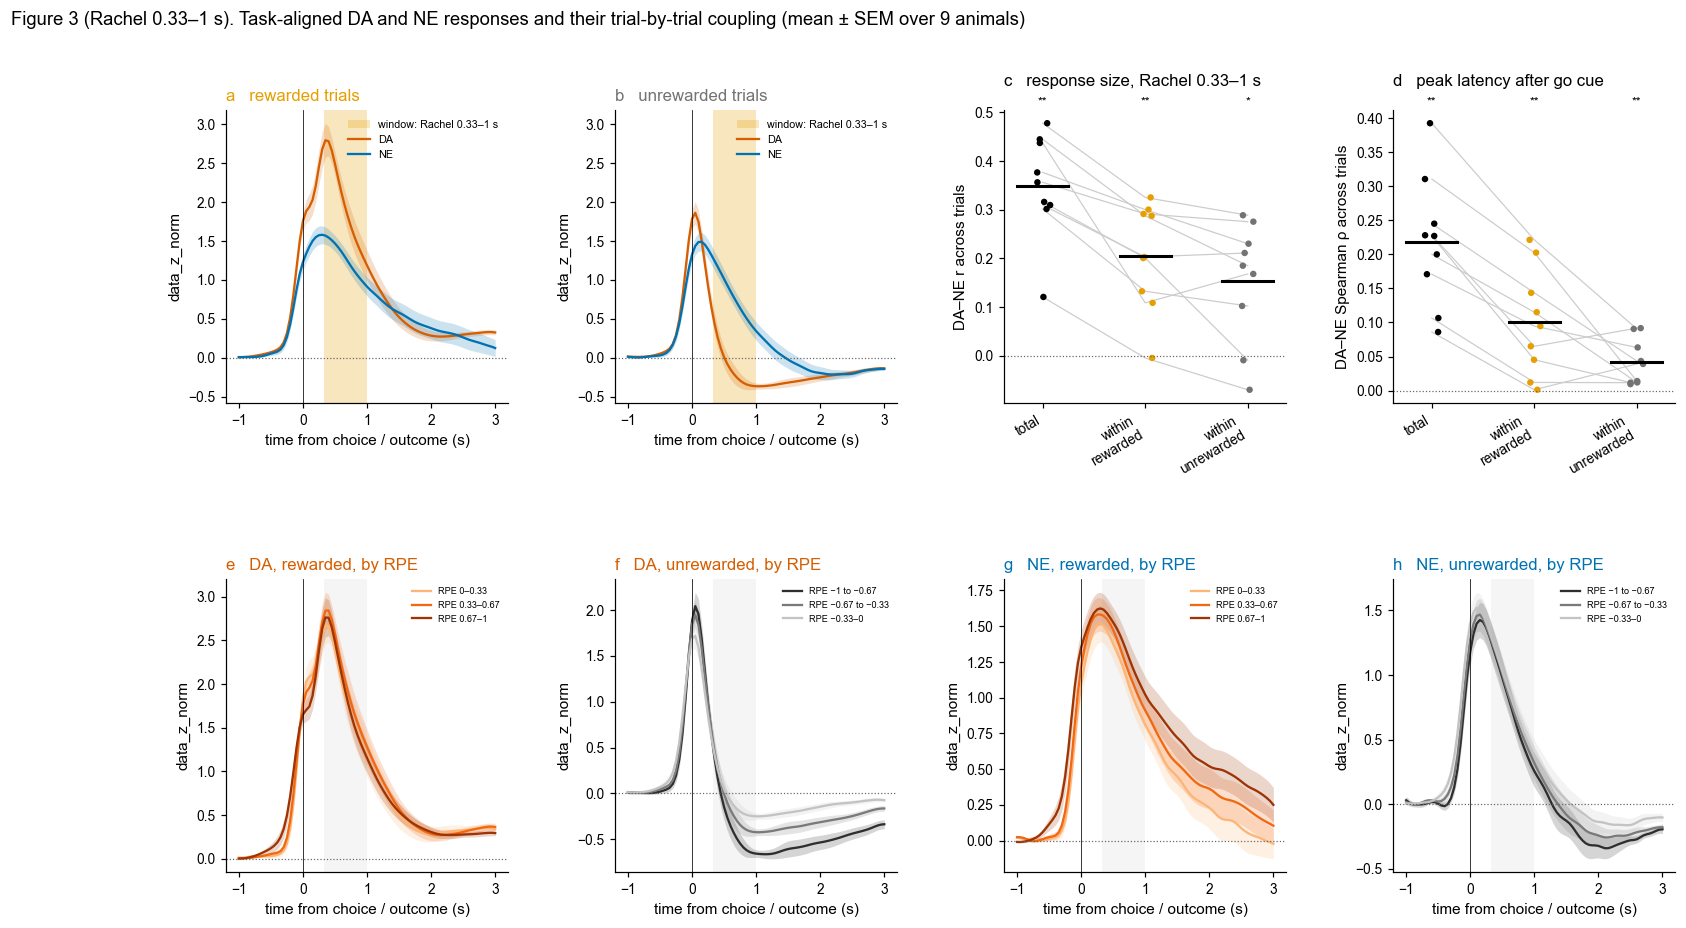

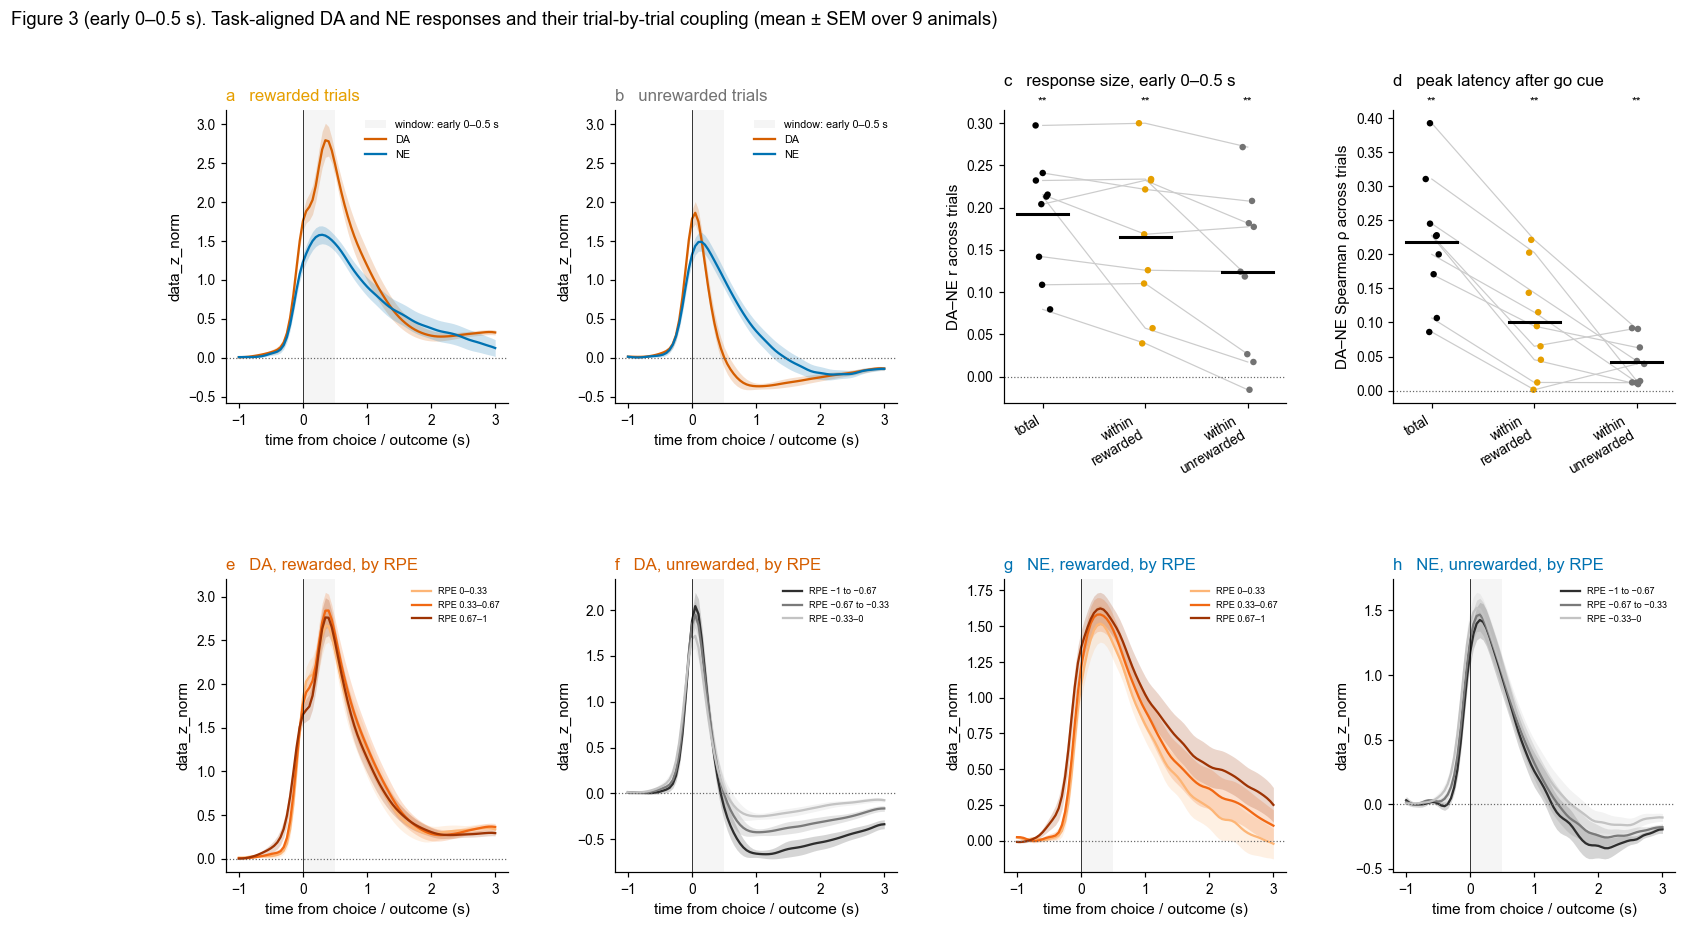

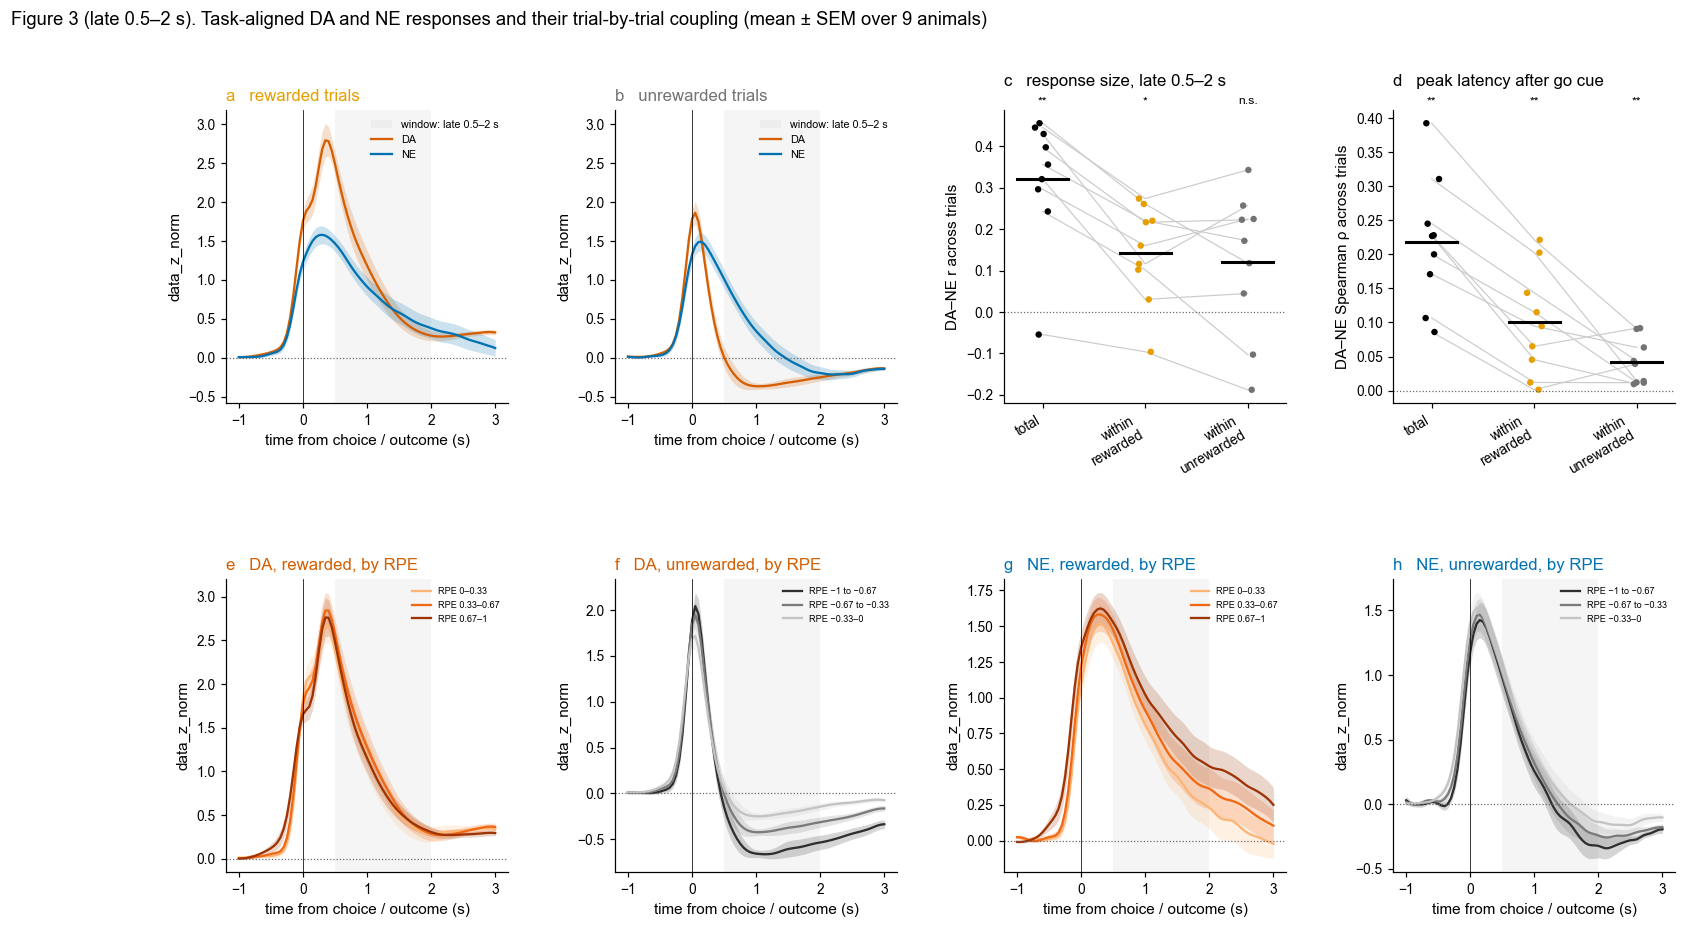

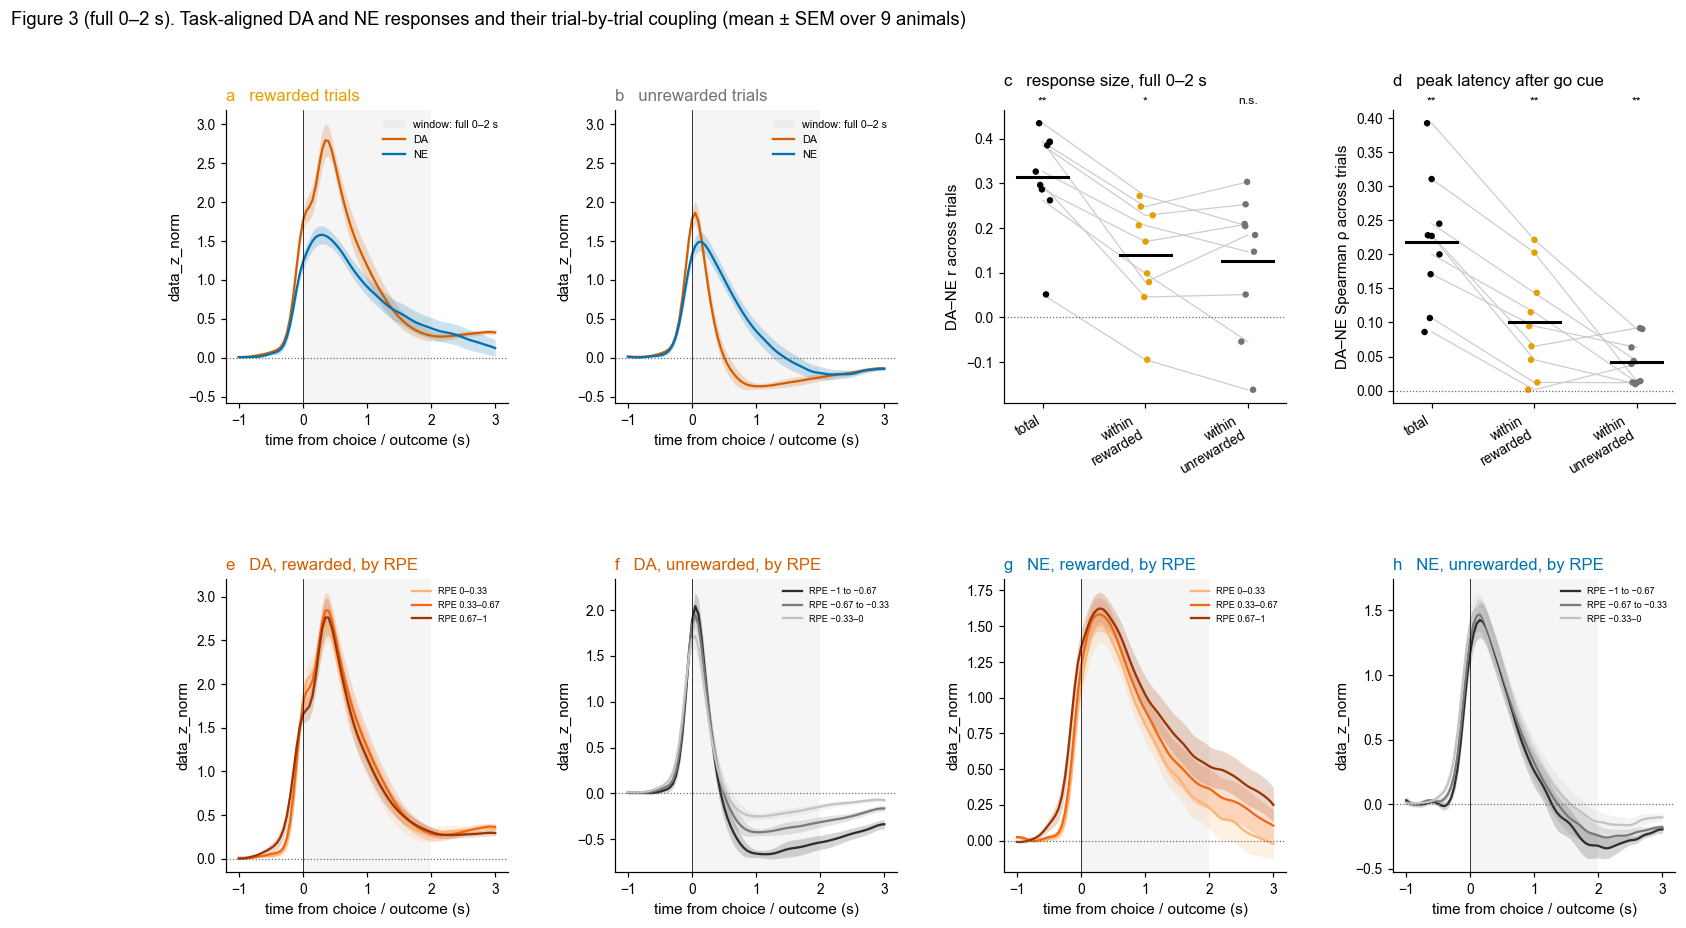

In [15]:
def make_fig3(w):
    a, b = WINDOWS[w]
    fig = plt.figure(figsize=(17, 9))
    gs = GridSpec(2, 4, figure=fig, hspace=0.6, wspace=0.38, top=0.88)

    ax0 = None
    for j, out in enumerate(("rewarded", "unrewarded")):
        ax = fig.add_subplot(gs[0, j], sharey=ax0)
        ax0 = ax0 or ax
        ax.axvspan(a, b, color=OUT_COLOR["rewarded"] if w == "rachel" else "0.85", alpha=0.25, lw=0,
                   label=f"window: {WINDOW_LABEL[w]}")
        for sig in ("da", "ne"):
            pu.plot_mean_sem(ax, PSTH_TIME, by_outcome[(sig, out)], SIG_COLOR[sig], sig.upper())
        ax.axvline(0, color="k", lw=0.5)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.set_xlabel("time from choice / outcome (s)")
        ax.set_ylabel("data_z_norm")
        ax.set_title(f"{'ab'[j]}   {out} trials", loc="left", color=OUT_COLOR[out])
        ax.legend(fontsize=7)
        style_ax(ax)

    ax = fig.add_subplot(gs[0, 2])
    pu.strip_by_measure(ax, size_corr, [f"{k}_{w}" for k in ("total", "rewarded", "unrewarded")],
                 ["total", "within\nrewarded", "within\nunrewarded"],
                 [TOTAL_COLOR, OUT_COLOR["rewarded"], OUT_COLOR["unrewarded"]],
                 "DA–NE r across trials", title=f"c   response size, {WINDOW_LABEL[w]}")
    ax = fig.add_subplot(gs[0, 3])
    pu.strip_by_measure(ax, lat_corr, ["total", "rewarded", "unrewarded"],
                 ["total", "within\nrewarded", "within\nunrewarded"],
                 [TOTAL_COLOR, OUT_COLOR["rewarded"], OUT_COLOR["unrewarded"]],
                 "DA–NE Spearman ρ across trials", title="d   peak latency after go cue")

    for j, (sig, out) in enumerate([(s, o) for s in ("da", "ne") for o in ("rewarded", "unrewarded")]):
        ax = fig.add_subplot(gs[1, j])
        ax.axvspan(a, b, color="0.85", alpha=0.25, lw=0)
        for k, q in enumerate(RPE_ORDER[out]):
            if (sig, (out, q)) in by_rpe:
                pu.plot_mean_sem(ax, PSTH_TIME, by_rpe[(sig, (out, q))], RPE_BIN_COLOR[out][k],
                            RPE_RANGE[(out, q)])
        ax.axvline(0, color="k", lw=0.5)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.set_xlabel("time from choice / outcome (s)")
        ax.set_ylabel("data_z_norm")
        ax.set_title(f"{'efgh'[j]}   {sig.upper()}, {out}, by RPE", loc="left", color=SIG_COLOR[sig])
        ax.legend(fontsize=6)
        style_ax(ax)
    fig.suptitle(f"Figure 3 ({WINDOW_LABEL[w]}). Task-aligned DA and NE responses and their "
                 f"trial-by-trial coupling (mean ± SEM over {N_ANIMALS} animals)", x=0.01, ha="left")
    save_fig(fig, f"fip_07_fig3_task_{w}", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()


for w in WINDOWS:
    make_fig3(w)

## Numbers behind each figure

One row per measure: mean of animal means, Wilcoxon p against zero, animals positive, the fraction
of sessions with p < 0.05 where a per-session test exists, and the median session z-score for tests
against a shift null.

In [16]:
def row(fig, measure, df, col, p=None, z=None):
    v = df.groupby("subject")[col].mean()
    m, pv, n = st.wilcoxon_animals(v)
    out = dict(figure=fig, measure=measure, mean=round(m, 3), p=round(pv, 4),
               animals_positive=f"{int((v > 0).sum())}/{n}", sessions_p_lt_05="",
               session_z_median="")
    if p is not None:
        d = df[[col, p]].dropna()
        out["sessions_p_lt_05"] = f"{int((d[p] < 0.05).sum())}/{len(d)}"
    if z is not None:
        out["session_z_median"] = f"{df[z].median():.1f}"
    return out


da_s, ne_s = solo_sess[solo_sess.sig == "da"], solo_sess[solo_sess.sig == "ne"]
S = [
    row("1", "peak r", xc_sess, "peak_r", "p_xc", "z_xc"),
    row("1", "peak |r| minus shift-null median", xc_sess, "peak_r_effect", "p_xc", "z_xc"),
    row("1", "peak lag (s, + = NE later)", xc_sess, "peak_lag"),
    row("1", "zero-lag r", xc_sess, "r0"),
    row("1", "coherence 0.02–2 Hz minus shift-null median", xc_sess, "coh_effect", "p_coh", "z_coh"),
    row("2", "large DA transients / min", da_s, "rate_per_min"),
    row("2", "large NE transients / min", ne_s, "rate_per_min"),
    row("2", "DA solo fraction", da_s, "solo_frac"),
    row("2", "NE solo fraction", ne_s, "solo_frac"),
    row("2", "DA → NE chance-corrected coupling", da_s, "coupling", "p_couple", "z_couple"),
    row("2", "NE → DA chance-corrected coupling", ne_s, "coupling", "p_couple", "z_couple"),
]
for w in WINDOWS:
    for k in SPLITS:
        S.append(row("3c", f"size r, {k}, {WINDOW_LABEL[w]}", size_sess, f"{k}_{w}", f"{k}_{w}_p"))
for k in SPLITS:
    S.append(row("3d", f"latency ρ, {k}", lat_sess, k, f"{k}_p"))
S += [row("3d", "NE − DA median latency, rewarded (s)", lat_sess, "ne_minus_da_rew"),
      row("3d", "NE − DA median latency, unrewarded (s)", lat_sess, "ne_minus_da_unrew")]
pd.DataFrame(S).set_index(["figure", "measure"])

mean       p animals_positive sessions_p_lt_05 session_z_median
figure measure                                                                                                       
1      peak r                                        0.272  0.0039              9/9            97/97             34.0
       peak |r| minus shift-null median              0.255  0.0039              9/9            97/97             34.0
       peak lag (s, + = NE later)                    0.023  0.3270              6/9                                  
       zero-lag r                                    0.260  0.0039              9/9                                  
       coherence 0.02–2 Hz minus shift-null median   0.064  0.0039              9/9            97/97             95.3
2      large DA transients / min                     8.722  0.0039              9/9                                  
       large NE transients / min                    20.315  0.0039              9/9                                  
       DA solo fraction                              0.174  0.0039              9/9                                  
       NE solo fraction                              0.551  0.0039              9/9                                  
       DA → NE chance-corrected coupling             0.521  0.0039              9/9            95/97             10.3
       NE → DA chance-corrected coupling             0.228  0.0039              9/9            96/97             16.9
3c     size r, total, Rachel 0.33–1 s                0.349  0.0039              9/9            93/97                 
       size r, rewarded, Rachel 0.33–1 s             0.205  0.0078              8/9            72/97                 
       size r, unrewarded, Rachel 0.33–1 s           0.153  0.0195              7/9            59/97                 
       size r, total, early 0–0.5 s                  0.192  0.0039              9/9            75/97                 
       size r, rewarded, early 0–0.5 s               0.165  0.0039              9/9            62/97                 
       size r, unrewarded, early 0–0.5 s             0.123  0.0078              8/9            53/97                 
       size r, total, late 0.5–2 s                   0.321  0.0078              8/9            91/97                 
       size r, rewarded, late 0.5–2 s                0.143  0.0117              8/9            60/97                 
       size r, unrewarded, late 0.5–2 s              0.121  0.0742              7/9            63/97                 
       size r, total, full 0–2 s                     0.314  0.0039              9/9            94/97                 
       size r, rewarded, full 0–2 s                  0.139  0.0195              8/9            62/97                 
       size r, unrewarded, full 0–2 s                0.126  0.0547              7/9            61/97                 
3d     latency ρ, total                              0.218  0.0039              9/9            67/97                 
       latency ρ, rewarded                           0.100  0.0039              9/9            25/97                 
       latency ρ, unrewarded                         0.042  0.0039              9/9            14/97                 
       NE − DA median latency, rewarded (s)          0.017  0.7344              4/9                                  
       NE − DA median latency, unrewarded (s)        0.157  0.0039              9/9